In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.distributions import gaussian

### **Part 1: Synthetic Gaussian Data**

#### **Shared Isotropic Covariance**

In [2]:
# generating 2D gaussian centered around 3 different means (3 classes)

rng = np.random.default_rng(42)
n = 10_000
means = np.array([[-2.0, -1.0], [4.0, 0.0], [1.0, 5.0]])

class_samples = []
for mean in means:
    X = np.column_stack((
        gaussian(mean[0], 1, n, rng),
        gaussian(mean[1], 1, n, rng)
    ))
    class_samples.append(X)

print([X.shape for X in class_samples])

[(10000, 2), (10000, 2), (10000, 2)]


In [3]:
# shuffling the data before spliting

np.random.seed(42)
indices = np.random.permutation(len(X[:, 0]))

shuffled_class_samples = []

for samples in class_samples:
    shuffled_samples = samples[indices]
    shuffled_class_samples.append(shuffled_samples)

In [4]:
# spliting the data points

train_end = int(0.8 * len(X[:, 0]))

train_class_samples = []
test_class_samples = []

for sample in shuffled_class_samples:
    train_class_samples.append(sample[:train_end, :])
    test_class_samples.append(sample[train_end:, :])

for i in range(len(train_class_samples)):
    print(f"Class {i+1} train_data shape : {train_class_samples[i].shape} and test_data shape : {test_class_samples[i].shape}")

Class 1 train_data shape : (8000, 2) and test_data shape : (2000, 2)
Class 2 train_data shape : (8000, 2) and test_data shape : (2000, 2)
Class 3 train_data shape : (8000, 2) and test_data shape : (2000, 2)


In [5]:
# estimating the parameters

train_class_mean_est = []
train_class_cov_est = []

for sample in train_class_samples:
    mu_hat = [sample[:, 0].mean(), sample[:, 1].mean()]
    train_class_mean_est.append(np.array([mu_hat[0], mu_hat[1]]))

print(train_class_mean_est)

[array([-2.00690185, -0.98401664]), array([ 4.01010049e+00, -2.02437662e-03]), array([1.00097768, 5.00330714])]


In [6]:
# one isotropic covariance shared by all three classes

squared_distance_sum = 0
for sample, mu_hat in zip(train_class_samples, train_class_mean_est):
    squared_distance_sum += np.sum((sample - mu_hat) ** 2)

total_points = sum(sample.shape[0] for sample in train_class_samples)
shared_variance = squared_distance_sum / (2 * total_points)
shared_cov_est = shared_variance * np.eye(2)

print("Shared variance:", shared_variance)
print("Shared covariance:\n", shared_cov_est)

Shared variance: 1.005064652491484
Shared covariance:
 [[1.00506465 0.        ]
 [0.         1.00506465]]


In [7]:
# Gaussian log score for one point and one class

def gaussian_score(point, mu, cov):
    difference = point - mu
    d_squared = difference @ np.linalg.inv(cov) @ difference
    return -0.5 * d_squared - 0.5 * np.log(np.linalg.det(cov))

# classify one held-out point
point = test_class_samples[0][0]
scores = [gaussian_score(point, mu_hat, shared_cov_est) for mu_hat in train_class_mean_est]
predicted_class = np.argmax(scores) + 1

print("Point:", point)
print("Gaussian scores:", scores)
print("Predicted class:", predicted_class)

Point: [-0.57639762 -2.62025687]
Gaussian scores: [np.float64(-2.3549626112433413), np.float64(-13.88033154327728), np.float64(-30.155769480793097)]
Predicted class: 1


In [8]:
# classify all held-out points

test_class_predictions = []
for sample in test_class_samples:
    predictions = []
    for point in sample:
        scores = [gaussian_score(point, mu_hat, shared_cov_est) for mu_hat in train_class_mean_est]
        predictions.append(np.argmax(scores) + 1)
    test_class_predictions.append(np.array(predictions))

print([len(predictions) for predictions in test_class_predictions])

[2000, 2000, 2000]


In [9]:
# rows: true class, columns: predicted class

confusion_matrix = np.zeros((3, 3), dtype=int)

for true_class, predictions in enumerate(test_class_predictions):
    for predicted_class in predictions:
        confusion_matrix[true_class, predicted_class - 1] += 1

print(confusion_matrix)
print("Accuracy:", np.trace(confusion_matrix) / confusion_matrix.sum())

[[1995    3    2]
 [   1 1995    4]
 [   2    4 1994]]
Accuracy: 0.9973333333333333


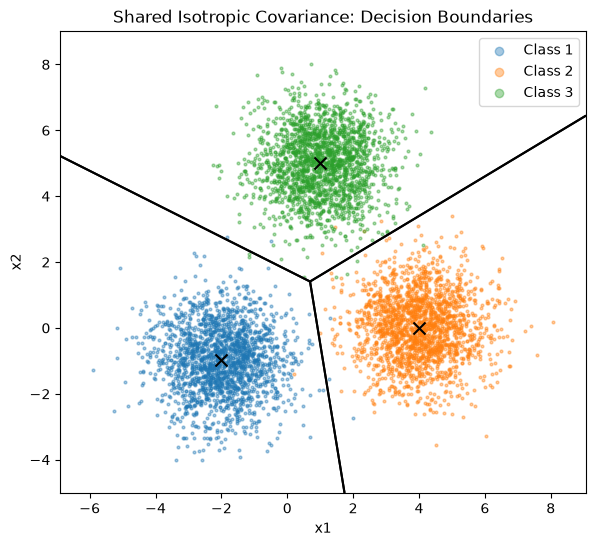

In [10]:
# decision regions from the estimated Gaussian scores

test_points = np.vstack(test_class_samples)
x_values = np.linspace(test_points[:, 0].min() - 1, test_points[:, 0].max() + 1, 400)
y_values = np.linspace(test_points[:, 1].min() - 1, test_points[:, 1].max() + 1, 400)
x_grid, y_grid = np.meshgrid(x_values, y_values)
grid_scores = np.zeros((3, *x_grid.shape))
for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        point = np.array([x_grid[i, j], y_grid[i, j]])
        grid_scores[:, i, j] = [gaussian_score(point, mu_hat, shared_cov_est) for mu_hat in train_class_mean_est]

class_colors = ["tab:blue", "tab:orange", "tab:green"]
plt.figure(figsize=(7, 6))
for k, sample in enumerate(test_class_samples):
    plt.scatter(sample[:, 0], sample[:, 1], s=4, alpha=0.4, color=class_colors[k], label=f"Class {k + 1}")
for k in range(3):
    other_scores = np.max(np.delete(grid_scores, k, axis=0), axis=0)
    plt.contour(x_grid, y_grid, grid_scores[k] - other_scores, levels=[0], colors="black")
for k, mu_hat in enumerate(train_class_mean_est):
    plt.scatter(mu_hat[0], mu_hat[1], marker="x", s=75, color="black")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Shared Isotropic Covariance: Decision Boundaries")
plt.gca().set_aspect("equal", adjustable="box")
plt.xlim(x_values[0], x_values[-1])
plt.ylim(y_values[0], y_values[-1])
plt.legend(markerscale=3)
plt.savefig("../docs/lab5/submissions/figures/shared_isotropic_boundary.png", dpi=150)
plt.show()

In [11]:
# class probabilities for the test points

probabilities = []
labels = []
for k, sample in enumerate(test_class_samples):
    for point in sample:
        scores = np.array([gaussian_score(point, mu_hat, shared_cov_est)
                       for mu_hat in train_class_mean_est])
        likelihoods = np.exp(scores - scores.max())
        probabilities.append(likelihoods / likelihoods.sum())
        labels.append(k + 1)
probabilities = np.array(probabilities)
labels = np.array(labels)


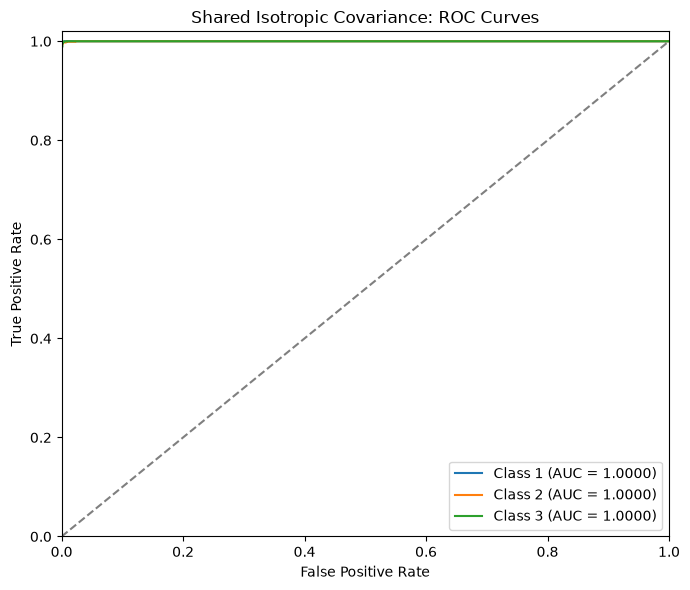

In [12]:
# vary the threshold for each class

plt.figure(figsize=(7, 6))
for k in range(3):
    positive = labels == k + 1
    positive_count = positive.sum()
    negative_count = len(labels) - positive_count
    fpr = [0]
    tpr = [0]
    thresholds = np.unique(probabilities[:, k])[::-1]
    for threshold in thresholds:
        predicted = probabilities[:, k] >= threshold
        tp = np.sum(predicted & positive)
        fp = np.sum(predicted & ~positive)
        tpr.append(tp / positive_count)
        fpr.append(fp / negative_count)
    auc = np.trapezoid(tpr, fpr)
    plt.plot(fpr, tpr, label=f"Class {k + 1} (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('Shared Isotropic Covariance: ROC Curves')
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../docs/lab5/submissions/figures/shared_isotropic_roc.png", dpi=150)
plt.show()


#### **Different Isotropic Covariances**

In [13]:
# three circular classes with different variances

unequal_isotropic_covariances = [np.eye(2), 2 * np.eye(2), 4 * np.eye(2)]
unequal_isotropic_samples = []
unequal_isotropic_rng = np.random.default_rng(43)

for mean, covariance in zip(means, unequal_isotropic_covariances):
    std = np.sqrt(covariance[0, 0])
    sample = np.column_stack((
        gaussian(mean[0], std, n, unequal_isotropic_rng),
        gaussian(mean[1], std, n, unequal_isotropic_rng)
    ))
    unequal_isotropic_samples.append(sample)

print([sample.shape for sample in unequal_isotropic_samples])

[(10000, 2), (10000, 2), (10000, 2)]


In [14]:
# shuffle and split each class as before

np.random.seed(43)
unequal_indices = np.random.permutation(n)

unequal_shuffled_samples = []
for sample in unequal_isotropic_samples:
    unequal_shuffled_samples.append(sample[unequal_indices])

unequal_train_samples = []
unequal_test_samples = []
train_end = int(0.8 * n)
for sample in unequal_shuffled_samples:
    unequal_train_samples.append(sample[:train_end, :])
    unequal_test_samples.append(sample[train_end:, :])

print([sample.shape for sample in unequal_train_samples])
print([sample.shape for sample in unequal_test_samples])

[(8000, 2), (8000, 2), (8000, 2)]
[(2000, 2), (2000, 2), (2000, 2)]


In [15]:
# estimate a mean and an isotropic covariance for each class

unequal_isotropic_mean_est = []
unequal_isotropic_cov_est = []

for sample in unequal_train_samples:
    mu_hat = np.array([sample[:, 0].mean(), sample[:, 1].mean()])
    variance = np.sum((sample - mu_hat) ** 2) / (2 * sample.shape[0])
    unequal_isotropic_mean_est.append(mu_hat)
    unequal_isotropic_cov_est.append(variance * np.eye(2))

for k in range(3):
    print(f"Class {k + 1} mean: {unequal_isotropic_mean_est[k]}")
    print(f"Class {k + 1} covariance:\n{unequal_isotropic_cov_est[k]}\n")

Class 1 mean: [-1.9840539  -0.99363456]
Class 1 covariance:
[[0.98429869 0.        ]
 [0.         0.98429869]]

Class 2 mean: [ 4.02040711 -0.00583171]
Class 2 covariance:
[[2.04170961 0.        ]
 [0.         2.04170961]]

Class 3 mean: [1.05101746 5.00772409]
Class 3 covariance:
[[4.06844716 0.        ]
 [0.         4.06844716]]



In [16]:
# classify the held-out points using each class's covariance
unequal_test_predictions = []
for sample in unequal_test_samples:
    predictions = []
    for point in sample:
        scores = [gaussian_score(point, mu_hat, covariance)
                  for mu_hat, covariance in zip(unequal_isotropic_mean_est, unequal_isotropic_cov_est)]
        predictions.append(np.argmax(scores) + 1)
    unequal_test_predictions.append(np.array(predictions))

print([len(predictions) for predictions in unequal_test_predictions])

[2000, 2000, 2000]


In [17]:
# rows: true class, columns: predicted class
unequal_confusion_matrix = np.zeros((3, 3), dtype=int)
for true_class, predictions in enumerate(unequal_test_predictions):
    for predicted_class in predictions:
        unequal_confusion_matrix[true_class, predicted_class - 1] += 1

print(unequal_confusion_matrix)
print("Accuracy:", np.trace(unequal_confusion_matrix) / unequal_confusion_matrix.sum())

[[1981    9   10]
 [   7 1928   65]
 [  18   97 1885]]
Accuracy: 0.9656666666666667


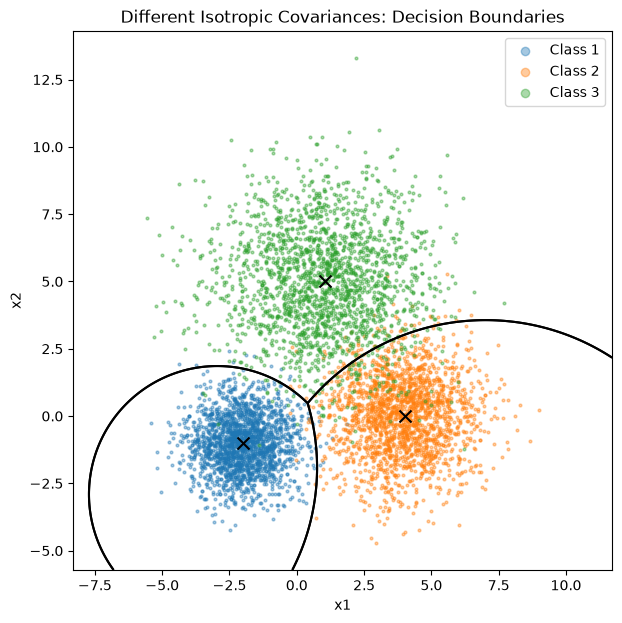

In [18]:
# decision boundaries with the test points
unequal_test_points = np.vstack(unequal_test_samples)
unequal_bounds_min = unequal_test_points.min(axis=0) - 1
unequal_bounds_max = unequal_test_points.max(axis=0) + 1
unequal_center = (unequal_bounds_min + unequal_bounds_max) / 2
unequal_half_width = max(unequal_bounds_max - unequal_bounds_min) / 2
unequal_x_values = np.linspace(unequal_center[0] - unequal_half_width, unequal_center[0] + unequal_half_width, 400)
unequal_y_values = np.linspace(unequal_center[1] - unequal_half_width, unequal_center[1] + unequal_half_width, 400)
unequal_x_grid, unequal_y_grid = np.meshgrid(unequal_x_values, unequal_y_values)
unequal_grid_scores = np.zeros((3, *unequal_x_grid.shape))
for i in range(unequal_x_grid.shape[0]):
    for j in range(unequal_x_grid.shape[1]):
        point = np.array([unequal_x_grid[i, j], unequal_y_grid[i, j]])
        unequal_grid_scores[:, i, j] = [gaussian_score(point, mu_hat, covariance)
                                        for mu_hat, covariance in zip(unequal_isotropic_mean_est, unequal_isotropic_cov_est)]

class_colors = ["tab:blue", "tab:orange", "tab:green"]
plt.figure(figsize=(7, 7))
for k, sample in enumerate(unequal_test_samples):
    plt.scatter(sample[:, 0], sample[:, 1], s=4, alpha=0.4, color=class_colors[k], label=f"Class {k + 1}")
for k in range(3):
    other_scores = np.max(np.delete(unequal_grid_scores, k, axis=0), axis=0)
    plt.contour(unequal_x_grid, unequal_y_grid, unequal_grid_scores[k] - other_scores, levels=[0], colors="black")
for k, mu_hat in enumerate(unequal_isotropic_mean_est):
    plt.scatter(mu_hat[0], mu_hat[1], marker="x", s=75, color="black")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Different Isotropic Covariances: Decision Boundaries")
plt.gca().set_aspect("equal", adjustable="box")
plt.xlim(unequal_x_values[0], unequal_x_values[-1])
plt.ylim(unequal_y_values[0], unequal_y_values[-1])
plt.legend(markerscale=3)
plt.savefig("../docs/lab5/submissions/figures/different_isotropic_boundary.png", dpi=150)
plt.show()

In [ ]:
# class probabilities for the test points
probabilities = []
labels = []
for k, sample in enumerate(unequal_test_samples):
    for point in sample:
        scores = np.array([gaussian_score(point, mu_hat, covariance)
                       for mu_hat, covariance in zip(unequal_isotropic_mean_est, unequal_isotropic_cov_est)])
        likelihoods = np.exp(scores - scores.max())
        probabilities.append(likelihoods / likelihoods.sum())
        labels.append(k + 1)
probabilities = np.array(probabilities)
labels = np.array(labels)

[1 1 1 ... 3 3 3]


(6000,)
(6000,)
(6000,)


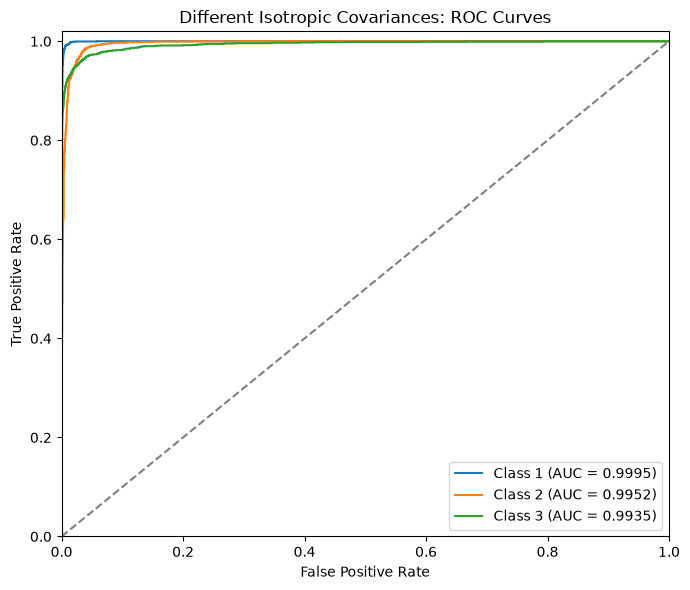

In [ ]:
# vary the threshold for each class
plt.figure(figsize=(7, 6))
for k in range(3):
    positive = labels == k + 1
    positive_count = positive.sum()
    negative_count = len(labels) - positive_count
    fpr = [0]
    tpr = [0]
    thresholds = np.unique(probabilities[:, k])[::-1]
    for threshold in thresholds:
        predicted = probabilities[:, k] >= threshold
        tp = np.sum(predicted & positive)
        fp = np.sum(predicted & ~positive)
        tpr.append(tp / positive_count)
        fpr.append(fp / negative_count)
    auc = np.trapezoid(tpr, fpr)
    plt.plot(fpr, tpr, label=f"Class {k + 1} (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('Different Isotropic Covariances: ROC Curves')
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../docs/lab5/submissions/figures/different_isotropic_roc.png", dpi=150)
plt.show()


#### **Shared Diagonal Covariance**


In [21]:
# same diagonal covariance for all three classes

shared_diagonal_true_cov = np.diag([2.0, 4.0])
shared_diagonal_std = np.sqrt(np.diag(shared_diagonal_true_cov))
shared_diagonal_samples = []
shared_diagonal_rng = np.random.default_rng(44)

for mean in means:
    sample = np.column_stack((
        gaussian(mean[0], shared_diagonal_std[0], n, shared_diagonal_rng),
        gaussian(mean[1], shared_diagonal_std[1], n, shared_diagonal_rng)
    ))
    shared_diagonal_samples.append(sample)

print([sample.shape for sample in shared_diagonal_samples])


[(10000, 2), (10000, 2), (10000, 2)]


In [22]:
# shuffle and split each class

np.random.seed(44)
shared_diagonal_indices = np.random.permutation(n)

shared_diagonal_train = []
shared_diagonal_test = []
train_end = int(0.8 * n)
for sample in shared_diagonal_samples:
    shuffled = sample[shared_diagonal_indices]
    shared_diagonal_train.append(shuffled[:train_end, :])
    shared_diagonal_test.append(shuffled[train_end:, :])

print([sample.shape for sample in shared_diagonal_train])
print([sample.shape for sample in shared_diagonal_test])


[(8000, 2), (8000, 2), (8000, 2)]
[(2000, 2), (2000, 2), (2000, 2)]


In [23]:
# estimate class means and one shared diagonal covariance

shared_diagonal_mean_est = []
for sample in shared_diagonal_train:
    shared_diagonal_mean_est.append(np.mean(sample, axis=0))

squared_residuals = np.zeros(2)
for sample, mu_hat in zip(shared_diagonal_train, shared_diagonal_mean_est):
    squared_residuals += np.sum((sample - mu_hat) ** 2, axis=0)

total_points = sum(sample.shape[0] for sample in shared_diagonal_train)
shared_diagonal_variances = squared_residuals / total_points
shared_diagonal_cov_est = np.diag(shared_diagonal_variances)

print("Estimated means:", shared_diagonal_mean_est)
print("Estimated shared covariance:\n", shared_diagonal_cov_est)

Estimated means: [array([-1.99341801, -1.01082158]), array([4.01139426, 0.0465701 ]), array([0.99727915, 4.96513231])]
Estimated shared covariance:
 [[1.99873726 0.        ]
 [0.         3.96529488]]


In [24]:
# classify test points and count predictions

shared_diagonal_predictions = []
for sample in shared_diagonal_test:
    predictions = []
    for point in sample:
        scores = [gaussian_score(point, mu_hat, shared_diagonal_cov_est)
                  for mu_hat in shared_diagonal_mean_est]
        predictions.append(np.argmax(scores) + 1)
    shared_diagonal_predictions.append(np.array(predictions))

shared_diagonal_confusion = np.zeros((3, 3), dtype=int)
for true_class, predictions in enumerate(shared_diagonal_predictions):
    for predicted_class in predictions:
        shared_diagonal_confusion[true_class, predicted_class - 1] += 1

print(shared_diagonal_confusion)
print("Accuracy:", np.trace(shared_diagonal_confusion) / shared_diagonal_confusion.sum())


[[1908   35   57]
 [  19 1882   99]
 [  75   96 1829]]
Accuracy: 0.9365


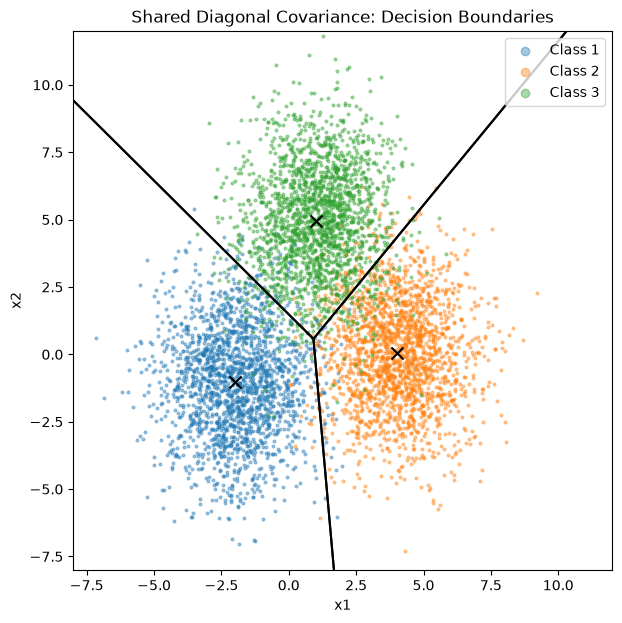

In [25]:
# score a square grid of points
values = np.linspace(-8, 12, 400)
x_grid, y_grid = np.meshgrid(values, values)
grid_scores = np.zeros((3, *x_grid.shape))
for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        point = np.array([x_grid[i, j], y_grid[i, j]])
        grid_scores[:, i, j] = [gaussian_score(point, mu_hat, shared_diagonal_cov_est)
                                for mu_hat in shared_diagonal_mean_est]

# draw points, boundaries, and estimated means
class_colors = ["tab:blue", "tab:orange", "tab:green"]
plt.figure(figsize=(7, 7))
for k, sample in enumerate(shared_diagonal_test):
    plt.scatter(sample[:, 0], sample[:, 1], s=4, alpha=0.4, color=class_colors[k], label=f"Class {k + 1}")
for k in range(3):
    other_scores = np.max(np.delete(grid_scores, k, axis=0), axis=0)
    plt.contour(x_grid, y_grid, grid_scores[k] - other_scores, levels=[0], colors="black")
for k, mu_hat in enumerate(shared_diagonal_mean_est):
    plt.scatter(mu_hat[0], mu_hat[1], marker="x", s=75, color="black")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Shared Diagonal Covariance: Decision Boundaries")
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(markerscale=3)
plt.savefig("../docs/lab5/submissions/figures/shared_diagonal_boundary.png", dpi=150)
plt.show()


In [26]:
# class probabilities for the test points
probabilities = []
labels = []
for k, sample in enumerate(shared_diagonal_test):
    for point in sample:
        scores = np.array([gaussian_score(point, mu_hat, shared_diagonal_cov_est)
                       for mu_hat in shared_diagonal_mean_est])
        likelihoods = np.exp(scores - scores.max())
        probabilities.append(likelihoods / likelihoods.sum())
        labels.append(k + 1)
probabilities = np.array(probabilities)
labels = np.array(labels)


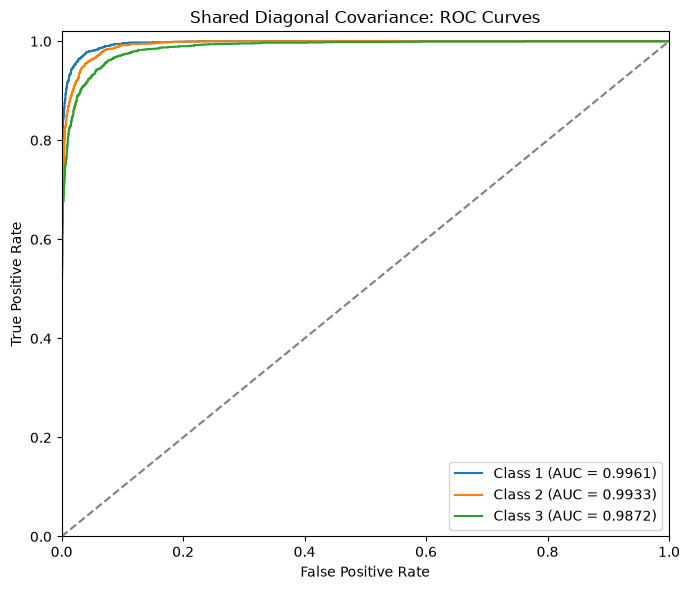

In [27]:
# vary the threshold for each class
plt.figure(figsize=(7, 6))
for k in range(3):
    positive = labels == k + 1
    positive_count = positive.sum()
    negative_count = len(labels) - positive_count
    fpr = [0]
    tpr = [0]
    thresholds = np.unique(probabilities[:, k])[::-1]
    for threshold in thresholds:
        predicted = probabilities[:, k] >= threshold
        tp = np.sum(predicted & positive)
        fp = np.sum(predicted & ~positive)
        tpr.append(tp / positive_count)
        fpr.append(fp / negative_count)
    auc = np.trapezoid(tpr, fpr)
    plt.plot(fpr, tpr, label=f"Class {k + 1} (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('Shared Diagonal Covariance: ROC Curves')
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../docs/lab5/submissions/figures/shared_diagonal_roc.png", dpi=150)
plt.show()


#### **Different Diagonal Covariances**


In [28]:
# each class has its own diagonal covariance
different_diagonal_covariances = [
    np.diag([1.0, 4.0]),
    np.diag([4.0, 1.0]),
    np.diag([2.0, 3.0])
]
different_diagonal_samples = []
different_diagonal_rng = np.random.default_rng(45)

for mean, covariance in zip(means, different_diagonal_covariances):
    std = np.sqrt(np.diag(covariance))
    sample = np.column_stack((
        gaussian(mean[0], std[0], n, different_diagonal_rng),
        gaussian(mean[1], std[1], n, different_diagonal_rng)
    ))
    different_diagonal_samples.append(sample)

print([sample.shape for sample in different_diagonal_samples])


[(10000, 2), (10000, 2), (10000, 2)]


In [29]:
# shuffle and split each class
np.random.seed(45)
different_diagonal_indices = np.random.permutation(n)

different_diagonal_train = []
different_diagonal_test = []
train_end = int(0.8 * n)
for sample in different_diagonal_samples:
    shuffled = sample[different_diagonal_indices]
    different_diagonal_train.append(shuffled[:train_end, :])
    different_diagonal_test.append(shuffled[train_end:, :])

print([sample.shape for sample in different_diagonal_train])
print([sample.shape for sample in different_diagonal_test])


[(8000, 2), (8000, 2), (8000, 2)]
[(2000, 2), (2000, 2), (2000, 2)]


In [30]:
# estimate one mean and diagonal covariance per class
different_diagonal_mean_est = []
different_diagonal_cov_est = []

for sample in different_diagonal_train:
    mu_hat = np.mean(sample, axis=0)
    variances = np.mean((sample - mu_hat) ** 2, axis=0)
    different_diagonal_mean_est.append(mu_hat)
    different_diagonal_cov_est.append(np.diag(variances))

for k in range(3):
    print(f"Class {k + 1} mean:", different_diagonal_mean_est[k])
    print(f"Class {k + 1} covariance:\n", different_diagonal_cov_est[k])


Class 1 mean: [-1.98293093 -0.99429175]
Class 1 covariance:
 [[1.00317345 0.        ]
 [0.         4.09484622]]
Class 2 mean: [ 3.99090654 -0.00686336]
Class 2 covariance:
 [[4.06601692 0.        ]
 [0.         1.00590425]]
Class 3 mean: [0.99900794 5.02399363]
Class 3 covariance:
 [[1.99629065 0.        ]
 [0.         3.02707909]]


In [31]:
# classify test points and count predictions
different_diagonal_predictions = []
for sample in different_diagonal_test:
    predictions = []
    for point in sample:
        scores = [gaussian_score(point, mu_hat, covariance)
                  for mu_hat, covariance in zip(different_diagonal_mean_est, different_diagonal_cov_est)]
        predictions.append(np.argmax(scores) + 1)
    different_diagonal_predictions.append(np.array(predictions))

different_diagonal_confusion = np.zeros((3, 3), dtype=int)
for true_class, predictions in enumerate(different_diagonal_predictions):
    for predicted_class in predictions:
        different_diagonal_confusion[true_class, predicted_class - 1] += 1

print(different_diagonal_confusion)
print("Accuracy:", np.trace(different_diagonal_confusion) / different_diagonal_confusion.sum())


[[1943   29   28]
 [  44 1927   29]
 [  40   46 1914]]
Accuracy: 0.964


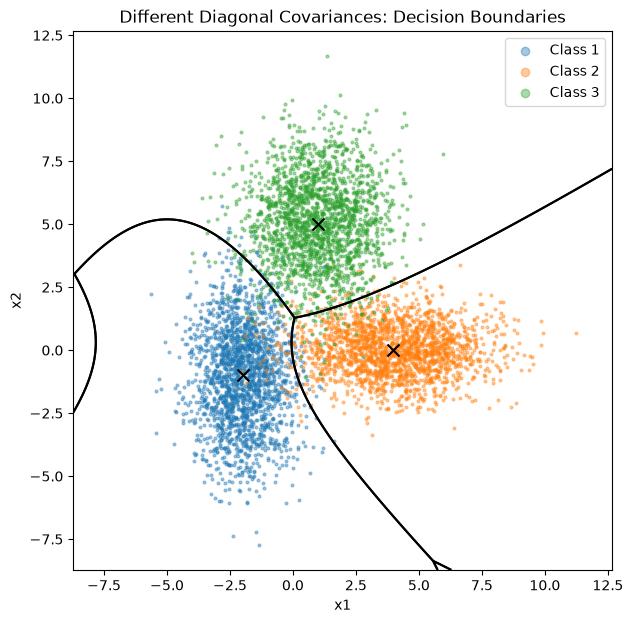

In [32]:
# score a square grid of points
test_points = np.vstack(different_diagonal_test)
values = np.linspace(test_points.min() - 1, test_points.max() + 1, 400)
x_grid, y_grid = np.meshgrid(values, values)
grid_scores = np.zeros((3, *x_grid.shape))
for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        point = np.array([x_grid[i, j], y_grid[i, j]])
        grid_scores[:, i, j] = [gaussian_score(point, mu_hat, covariance)
                                for mu_hat, covariance in zip(different_diagonal_mean_est, different_diagonal_cov_est)]

# draw points, boundaries, and estimated means
class_colors = ["tab:blue", "tab:orange", "tab:green"]
plt.figure(figsize=(7, 7))
for k, sample in enumerate(different_diagonal_test):
    plt.scatter(sample[:, 0], sample[:, 1], s=4, alpha=0.4, color=class_colors[k], label=f"Class {k + 1}")
for k in range(3):
    other_scores = np.max(np.delete(grid_scores, k, axis=0), axis=0)
    plt.contour(x_grid, y_grid, grid_scores[k] - other_scores, levels=[0], colors="black")
for k, mu_hat in enumerate(different_diagonal_mean_est):
    plt.scatter(mu_hat[0], mu_hat[1], marker="x", s=75, color="black")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Different Diagonal Covariances: Decision Boundaries")
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(markerscale=3)
plt.savefig("../docs/lab5/submissions/figures/different_diagonal_boundary.png", dpi=150)
plt.show()


In [33]:
# class probabilities for the test points
probabilities = []
labels = []
for k, sample in enumerate(different_diagonal_test):
    for point in sample:
        scores = np.array([gaussian_score(point, mu_hat, covariance)
                       for mu_hat, covariance in zip(different_diagonal_mean_est, different_diagonal_cov_est)])
        likelihoods = np.exp(scores - scores.max())
        probabilities.append(likelihoods / likelihoods.sum())
        labels.append(k + 1)
probabilities = np.array(probabilities)
labels = np.array(labels)


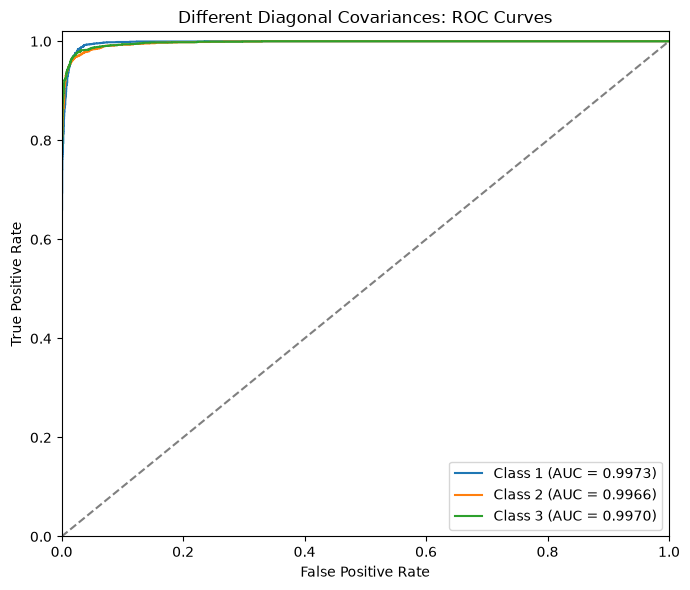

In [34]:
# vary the threshold for each class
plt.figure(figsize=(7, 6))
for k in range(3):
    positive = labels == k + 1
    positive_count = positive.sum()
    negative_count = len(labels) - positive_count
    fpr = [0]
    tpr = [0]
    thresholds = np.unique(probabilities[:, k])[::-1]
    for threshold in thresholds:
        predicted = probabilities[:, k] >= threshold
        tp = np.sum(predicted & positive)
        fp = np.sum(predicted & ~positive)
        tpr.append(tp / positive_count)
        fpr.append(fp / negative_count)
    auc = np.trapezoid(tpr, fpr)
    plt.plot(fpr, tpr, label=f"Class {k + 1} (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('Different Diagonal Covariances: ROC Curves')
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../docs/lab5/submissions/figures/different_diagonal_roc.png", dpi=150)
plt.show()


#### **Shared Full Covariance**


In [35]:
# one tilted covariance for all three classes
shared_full_true_cov = np.array([[2.0, -1.0], [-1.0, 2.0]])
eigenvalues, eigenvectors = np.linalg.eigh(shared_full_true_cov)
shared_full_cov_sqrt = eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.T
shared_full_rng = np.random.default_rng(46)
shared_full_samples = []

for mean in means:
    standard_samples = np.column_stack((
        gaussian(0, 1, n, shared_full_rng),
        gaussian(0, 1, n, shared_full_rng)
    ))
    shared_full_samples.append(standard_samples @ shared_full_cov_sqrt.T + mean)

print([sample.shape for sample in shared_full_samples])


[(10000, 2), (10000, 2), (10000, 2)]


In [36]:
# shuffle and split each class
np.random.seed(46)
shared_full_indices = np.random.permutation(n)
shared_full_train = []
shared_full_test = []
train_end = int(0.8 * n)

for sample in shared_full_samples:
    shuffled = sample[shared_full_indices]
    shared_full_train.append(shuffled[:train_end, :])
    shared_full_test.append(shuffled[train_end:, :])

print([sample.shape for sample in shared_full_train])
print([sample.shape for sample in shared_full_test])


[(8000, 2), (8000, 2), (8000, 2)]
[(2000, 2), (2000, 2), (2000, 2)]


In [37]:
# estimate class means and one shared full covariance
shared_full_mean_est = []
for sample in shared_full_train:
    shared_full_mean_est.append(np.mean(sample, axis=0))

covariance_sum = np.zeros((2, 2))
for sample, mu_hat in zip(shared_full_train, shared_full_mean_est):
    residuals = sample - mu_hat
    covariance_sum += residuals.T @ residuals

total_points = sum(sample.shape[0] for sample in shared_full_train)
shared_full_cov_est = covariance_sum / total_points

print("Estimated means:", shared_full_mean_est)
print("Estimated shared covariance:", shared_full_cov_est)
print("True shared covariance:", shared_full_true_cov)


Estimated means: [array([-2.01468003, -0.99412497]), array([ 4.06263692, -0.03392729]), array([1.03169336, 4.99504827])]
Estimated shared covariance: [[ 2.00366561 -1.00309923]
 [-1.00309923  2.00955854]]
True shared covariance: [[ 2. -1.]
 [-1.  2.]]


In [38]:
# classify test points and count predictions
shared_full_predictions = []
for sample in shared_full_test:
    predictions = []
    for point in sample:
        scores = [gaussian_score(point, mu_hat, shared_full_cov_est)
                  for mu_hat in shared_full_mean_est]
        predictions.append(np.argmax(scores) + 1)
    shared_full_predictions.append(np.array(predictions))

shared_full_confusion = np.zeros((3, 3), dtype=int)
for true_class, predictions in enumerate(shared_full_predictions):
    for predicted_class in predictions:
        shared_full_confusion[true_class, predicted_class - 1] += 1

print(shared_full_confusion)
print("Accuracy:", np.trace(shared_full_confusion) / shared_full_confusion.sum())


[[1992    7    1]
 [  10 1917   73]
 [   2   63 1935]]
Accuracy: 0.974


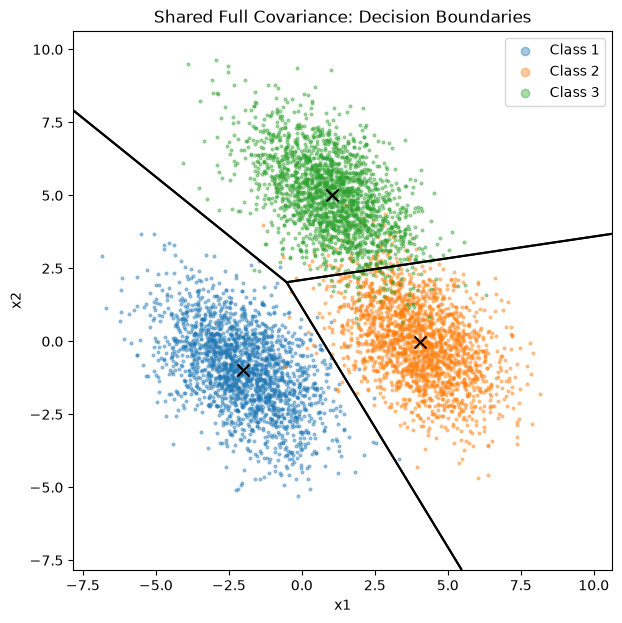

In [39]:
# score a square grid of points
test_points = np.vstack(shared_full_test)
values = np.linspace(test_points.min() - 1, test_points.max() + 1, 400)
x_grid, y_grid = np.meshgrid(values, values)
grid_scores = np.zeros((3, *x_grid.shape))
for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        point = np.array([x_grid[i, j], y_grid[i, j]])
        grid_scores[:, i, j] = [gaussian_score(point, mu_hat, shared_full_cov_est)
                                for mu_hat in shared_full_mean_est]

# draw points, boundaries, and estimated means
class_colors = ["tab:blue", "tab:orange", "tab:green"]
plt.figure(figsize=(7, 7))
for k, sample in enumerate(shared_full_test):
    plt.scatter(sample[:, 0], sample[:, 1], s=4, alpha=0.4, color=class_colors[k], label=f"Class {k + 1}")
for k in range(3):
    other_scores = np.max(np.delete(grid_scores, k, axis=0), axis=0)
    plt.contour(x_grid, y_grid, grid_scores[k] - other_scores, levels=[0], colors="black")
for k, mu_hat in enumerate(shared_full_mean_est):
    plt.scatter(mu_hat[0], mu_hat[1], marker="x", s=75, color="black")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Shared Full Covariance: Decision Boundaries")
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(markerscale=3)
plt.savefig("../docs/lab5/submissions/figures/shared_full_boundary.png", dpi=150)
plt.show()

In [40]:
# class probabilities for the test points
probabilities = []
labels = []
for k, sample in enumerate(shared_full_test):
    for point in sample:
        scores = np.array([gaussian_score(point, mu_hat, shared_full_cov_est)
                       for mu_hat in shared_full_mean_est])
        likelihoods = np.exp(scores - scores.max())
        probabilities.append(likelihoods / likelihoods.sum())
        labels.append(k + 1)
probabilities = np.array(probabilities)
labels = np.array(labels)


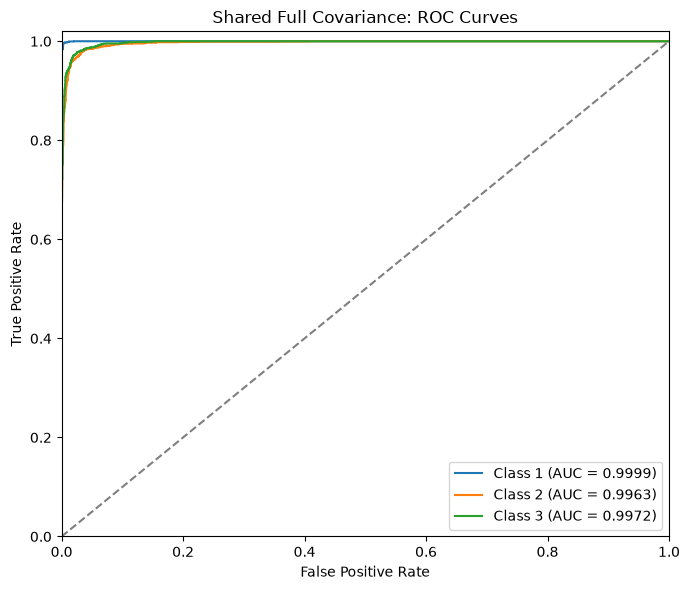

In [41]:
# vary the threshold for each class
plt.figure(figsize=(7, 6))
for k in range(3):
    positive = labels == k + 1
    positive_count = positive.sum()
    negative_count = len(labels) - positive_count
    fpr = [0]
    tpr = [0]
    thresholds = np.unique(probabilities[:, k])[::-1]
    for threshold in thresholds:
        predicted = probabilities[:, k] >= threshold
        tp = np.sum(predicted & positive)
        fp = np.sum(predicted & ~positive)
        tpr.append(tp / positive_count)
        fpr.append(fp / negative_count)
    auc = np.trapezoid(tpr, fpr)
    plt.plot(fpr, tpr, label=f"Class {k + 1} (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('Shared Full Covariance: ROC Curves')
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../docs/lab5/submissions/figures/shared_full_roc.png", dpi=150)
plt.show()


#### **Different Full Covariances**


In [42]:
# each class has a different tilted covariance
different_full_covariances = [
    np.array([[2.0, 1.0], [1.0, 2.0]]),
    np.array([[3.0, -1.0], [-1.0, 2.0]]),
    np.array([[2.0, -1.0], [-1.0, 3.0]])
]
different_full_rng = np.random.default_rng(47)
different_full_samples = []

for mean, covariance in zip(means, different_full_covariances):
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    cov_sqrt = eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.T
    standard_samples = np.column_stack((
        gaussian(0, 1, n, different_full_rng),
        gaussian(0, 1, n, different_full_rng)
    ))
    different_full_samples.append(standard_samples @ cov_sqrt.T + mean)

print([sample.shape for sample in different_full_samples])


[(10000, 2), (10000, 2), (10000, 2)]


In [43]:
# shuffle and split each class
np.random.seed(47)
different_full_indices = np.random.permutation(n)
different_full_train = []
different_full_test = []
train_end = int(0.8 * n)

for sample in different_full_samples:
    shuffled = sample[different_full_indices]
    different_full_train.append(shuffled[:train_end, :])
    different_full_test.append(shuffled[train_end:, :])

print([sample.shape for sample in different_full_train])
print([sample.shape for sample in different_full_test])


[(8000, 2), (8000, 2), (8000, 2)]
[(2000, 2), (2000, 2), (2000, 2)]


In [44]:
# estimate a mean and full covariance for each class
different_full_mean_est = []
different_full_cov_est = []

for sample in different_full_train:
    mu_hat = np.mean(sample, axis=0)
    residuals = sample - mu_hat
    cov_hat = residuals.T @ residuals / sample.shape[0]
    different_full_mean_est.append(mu_hat)
    different_full_cov_est.append(cov_hat)

for k in range(3):
    print(f"Class {k + 1} mean:", different_full_mean_est[k])
    print(f"Class {k + 1} estimated covariance:\n", different_full_cov_est[k])

Class 1 mean: [-1.97731425 -1.00131036]
Class 1 estimated covariance:
 [[2.00729321 0.99463854]
 [0.99463854 1.96193294]]
Class 2 mean: [ 3.99418374 -0.00443057]
Class 2 estimated covariance:
 [[ 2.99737783 -1.01189412]
 [-1.01189412  2.0162594 ]]
Class 3 mean: [1.03184165 4.97155575]
Class 3 estimated covariance:
 [[ 1.98109545 -1.02127874]
 [-1.02127874  2.98043859]]


In [45]:
# classify test points and count predictions
different_full_predictions = []
for sample in different_full_test:
    predictions = []
    for point in sample:
        scores = [gaussian_score(point, mu_hat, covariance)
                  for mu_hat, covariance in zip(different_full_mean_est, different_full_cov_est)]
        predictions.append(np.argmax(scores) + 1)
    different_full_predictions.append(np.array(predictions))

different_full_confusion = np.zeros((3, 3), dtype=int)
for true_class, predictions in enumerate(different_full_predictions):
    for predicted_class in predictions:
        different_full_confusion[true_class, predicted_class - 1] += 1

print(different_full_confusion)
print("Accuracy:", np.trace(different_full_confusion) / different_full_confusion.sum())


[[1947   37   16]
 [  47 1859   94]
 [  11   93 1896]]
Accuracy: 0.9503333333333334


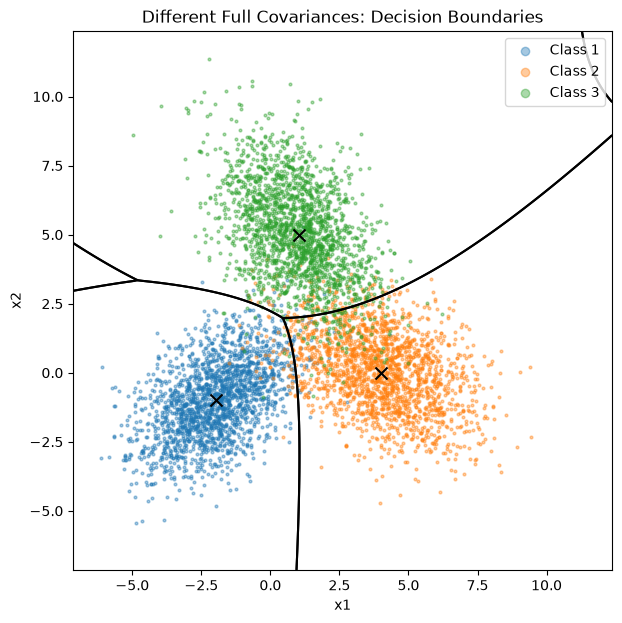

In [46]:
# score a square grid of points
test_points = np.vstack(different_full_test)
values = np.linspace(test_points.min() - 1, test_points.max() + 1, 400)
x_grid, y_grid = np.meshgrid(values, values)
grid_scores = np.zeros((3, *x_grid.shape))
for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        point = np.array([x_grid[i, j], y_grid[i, j]])
        grid_scores[:, i, j] = [gaussian_score(point, mu_hat, covariance)
                                for mu_hat, covariance in zip(different_full_mean_est, different_full_cov_est)]

# draw points, boundaries, and estimated means
class_colors = ["tab:blue", "tab:orange", "tab:green"]
plt.figure(figsize=(7, 7))
for k, sample in enumerate(different_full_test):
    plt.scatter(sample[:, 0], sample[:, 1], s=4, alpha=0.4, color=class_colors[k], label=f"Class {k + 1}")
for k in range(3):
    other_scores = np.max(np.delete(grid_scores, k, axis=0), axis=0)
    plt.contour(x_grid, y_grid, grid_scores[k] - other_scores, levels=[0], colors="black")
for k, mu_hat in enumerate(different_full_mean_est):
    plt.scatter(mu_hat[0], mu_hat[1], marker="x", s=75, color="black")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Different Full Covariances: Decision Boundaries")
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(markerscale=3)
plt.savefig("../docs/lab5/submissions/figures/different_full_boundary.png", dpi=150)
plt.show()

In [47]:
# class probabilities for the test points
probabilities = []
labels = []
for k, sample in enumerate(different_full_test):
    for point in sample:
        scores = np.array([gaussian_score(point, mu_hat, covariance)
                       for mu_hat, covariance in zip(different_full_mean_est, different_full_cov_est)])
        likelihoods = np.exp(scores - scores.max())
        probabilities.append(likelihoods / likelihoods.sum())
        labels.append(k + 1)
probabilities = np.array(probabilities)
labels = np.array(labels)


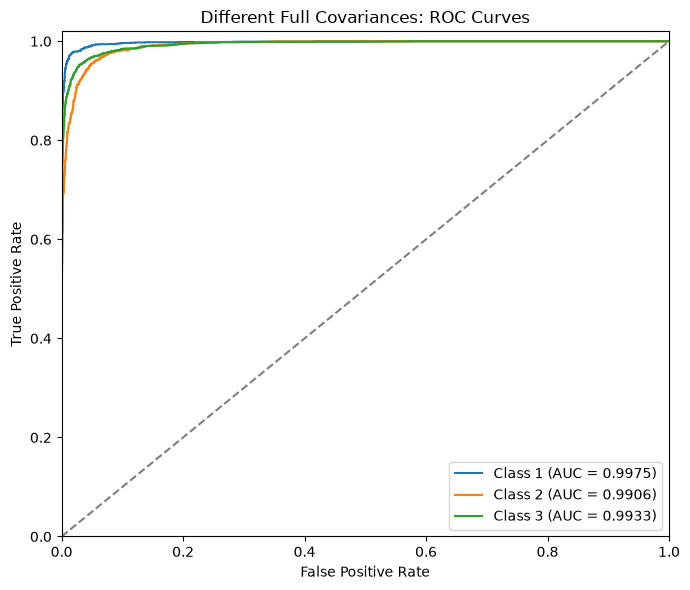

In [48]:
# vary the threshold for each class

plt.figure(figsize=(7, 6))
for k in range(3):
    positive = labels == k + 1
    positive_count = positive.sum()
    negative_count = len(labels) - positive_count
    fpr = [0]
    tpr = [0]
    thresholds = np.unique(probabilities[:, k])[::-1]
    for threshold in thresholds:
        predicted = probabilities[:, k] >= threshold
        tp = np.sum(predicted & positive)
        fp = np.sum(predicted & ~positive)
        tpr.append(tp / positive_count)
        fpr.append(fp / negative_count)
    auc = np.trapezoid(tpr, fpr)
    plt.plot(fpr, tpr, label=f"Class {k + 1} (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('Different Full Covariances: ROC Curves')
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../docs/lab5/submissions/figures/different_full_roc.png", dpi=150)
plt.show()


### **Part 2: Given 2D Data**

In [49]:
# use the supplied training and development sets
train_data = np.loadtxt("./data/trian.txt", delimiter=",")
test_data = np.loadtxt("./data/dev.txt", delimiter=",")

real_train = []
real_test = []
for class_label in [1, 2, 3]:
    real_train.append(train_data[train_data[:, 2] == class_label, :2])
    real_test.append(test_data[test_data[:, 2] == class_label, :2])

print("Training points:", [sample.shape for sample in real_train])
print("Test points:", [sample.shape for sample in real_test])


Training points: [(350, 2), (350, 2), (350, 2)]
Test points: [(100, 2), (100, 2), (100, 2)]


In [50]:
# estimate one mean and full covariance for each class
real_mean_est = []
real_cov_est = []

for sample in real_train:
    mu_hat = np.mean(sample, axis=0)
    residuals = sample - mu_hat
    cov_hat = residuals.T @ residuals / sample.shape[0]
    real_mean_est.append(mu_hat)
    real_cov_est.append(cov_hat)

for k in range(3):
    print(f"Class {k + 1} mean:", real_mean_est[k])
    print(f"Class {k + 1} covariance:\n", real_cov_est[k])


Class 1 mean: [ 580.61565714 1442.99285714]
Class 1 covariance:
 [[21843.04672343  3347.87598755]
 [ 3347.87598755 51710.37108669]]
Class 2 mean: [ 413.42285714 1914.332     ]
Class 2 covariance:
 [[13657.82598784 -9564.80753429]
 [-9564.80753429 47033.19331886]]
Class 3 mean: [ 412.49734286 1227.97614286]
Class 3 covariance:
 [[ 24311.72102351  36852.20944261]
 [ 36852.20944261 166270.47665684]]


In [51]:
# classify the test points with the Gaussian score from Part 1
real_predictions = []
for sample in real_test:
    predictions = []
    for point in sample:
        scores = [gaussian_score(point, mu_hat, covariance)
                  for mu_hat, covariance in zip(real_mean_est, real_cov_est)]
        predictions.append(np.argmax(scores) + 1)
    real_predictions.append(np.array(predictions))

real_confusion = np.zeros((3, 3), dtype=int)
for true_class, predictions in enumerate(real_predictions):
    for predicted_class in predictions:
        real_confusion[true_class, predicted_class - 1] += 1

print("Confusion matrix (rows: true, columns: predicted):")
print(real_confusion)
print("Accuracy:", np.trace(real_confusion) / real_confusion.sum())


Confusion matrix (rows: true, columns: predicted):
[[80 10 10]
 [11 85  4]
 [21  4 75]]
Accuracy: 0.8


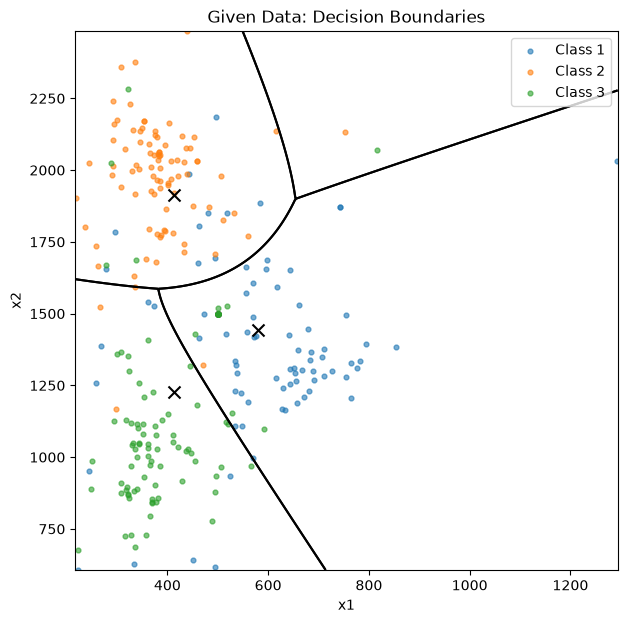

In [ ]:
# plot the decision boundaries with the test points
real_test_points = np.vstack(real_test)
x_values = np.linspace(real_test_points[:, 0].min() - 1,
                       real_test_points[:, 0].max() + 1, 300)
y_values = np.linspace(real_test_points[:, 1].min() - 1,
                       real_test_points[:, 1].max() + 1, 300)
x_grid, y_grid = np.meshgrid(x_values, y_values)
grid_scores = np.zeros((3, *x_grid.shape))
for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        point = np.array([x_grid[i, j], y_grid[i, j]])
        grid_scores[:, i, j] = [gaussian_score(point, mu_hat, covariance)
                                for mu_hat, covariance in zip(real_mean_est, real_cov_est)]

class_colors = ["tab:blue", "tab:orange", "tab:green"]
plt.figure(figsize=(7, 7))
for k, sample in enumerate(real_test):
    plt.scatter(sample[:, 0], sample[:, 1], s=12, alpha=0.6,i
                color=class_colors[k], label=f"Class {k + 1}")
for k in range(3):
    other_scores = np.max(np.delete(grid_scores, k, axis=0), axis=0)
    plt.contour(x_grid, y_grid, grid_scores[k] - other_scores,
                levels=[0], colors="black")
for mu_hat in real_mean_est:
    plt.scatter(mu_hat[0], mu_hat[1], marker="x", s=75, color="black")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Given Data: Decision Boundaries")
plt.legend()
plt.savefig("../docs/lab5/submissions/figures/given_data_boundary.png", dpi=150)
plt.show()


In [53]:
# class probabilities for the test points
probabilities = []
labels = []
for k, sample in enumerate(real_test):
    for point in sample:
        scores = np.array([gaussian_score(point, mu_hat, covariance)
                       for mu_hat, covariance in zip(real_mean_est, real_cov_est)])
        likelihoods = np.exp(scores - scores.max())
        probabilities.append(likelihoods / likelihoods.sum())
        labels.append(k + 1)
probabilities = np.array(probabilities)
labels = np.array(labels)


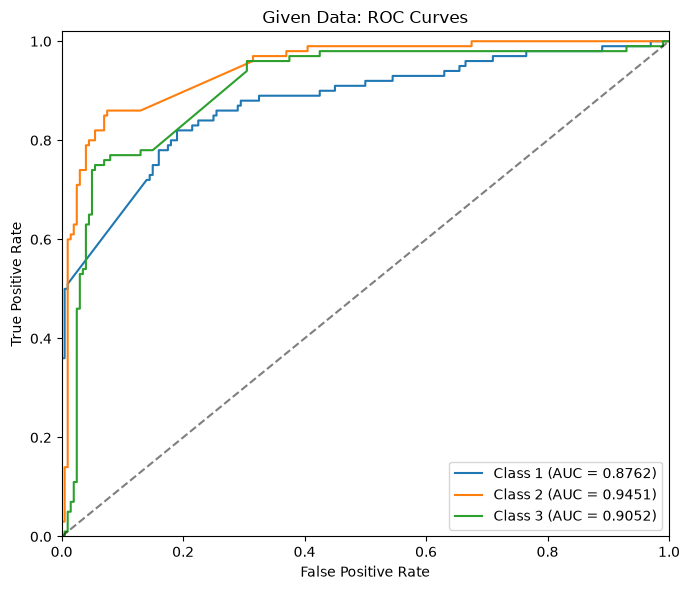

In [54]:
# vary the threshold for each class
plt.figure(figsize=(7, 6))
for k in range(3):
    positive = labels == k + 1
    positive_count = positive.sum()
    negative_count = len(labels) - positive_count
    fpr = [0]
    tpr = [0]
    thresholds = np.unique(probabilities[:, k])[::-1]
    for threshold in thresholds:
        predicted = probabilities[:, k] >= threshold
        tp = np.sum(predicted & positive)
        fp = np.sum(predicted & ~positive)
        tpr.append(tp / positive_count)
        fpr.append(fp / negative_count)
    auc = np.trapezoid(tpr, fpr)
    plt.plot(fpr, tpr, label=f"Class {k + 1} (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('Given Data: ROC Curves')
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../docs/lab5/submissions/figures/given_data_roc.png", dpi=150)
plt.show()
